In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import kurtosis
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Leer el dataset
df = pd.read_csv(r"../Datos/Accidentes de Transito - Dataset.csv")


In [64]:
import pandas as pd

df = pd.read_csv(r"../Datos/Accidentes de Transito - Dataset.csv")

df.head()

,Mes,Año,Accidentes,Temperatura Prom. del Mes (°C),Acum. Lluvia Diaria,Días Hábiles del mes,Inicio de Clases,Precio Gasolina (95 Octanos),Accidentes del mes anterior,IMAE
0,Enero,2017,2683,27.15,0.00,22,0,0.77,3237,309.60
1,Febrero,2017,2606,27.35,18.50,20,0,0.75,2683,312.23
2,Marzo,2017,3033,28.55,6.35,23,1,0.73,2606,315.04
3,Abril,2017,2738,28.70,60.50,20,0,0.75,3033,317.64
4,Mayo,2017,2972,27.85,228.95,23,0,0.75,2738,319.50


En este proyecto se excluyó el periodo comprendido entre marzo de 2020 y agosto de 2021, correspondiente a la pandemia de COVID-19. Se consideró que este intervalo no representa condiciones normales de tráfico, ya que las restricciones de movilidad y demás medidas sanitarias generan un comportamiento atípico en la accidentalidad. Por esta razón, el análisis se centra únicamente en periodos que reflejan condiciones normales de circulación vehicular.

Las variables Días Hábiles del mes e Inicio de Clases fueron calculadas manualmente con base en el calendario oficial de cada año.

## Información del conjunto de datos

In [65]:
# Vista general del dataset
df.head()

,Mes,Año,Accidentes,Temperatura Prom. del Mes (°C),Acum. Lluvia Diaria,Días Hábiles del mes,Inicio de Clases,Precio Gasolina (95 Octanos),Accidentes del mes anterior,IMAE
0,Enero,2017,2683,27.15,0.00,22,0,0.77,3237,309.60
1,Febrero,2017,2606,27.35,18.50,20,0,0.75,2683,312.23
2,Marzo,2017,3033,28.55,6.35,23,1,0.73,2606,315.04
3,Abril,2017,2738,28.70,60.50,20,0,0.75,3033,317.64
4,Mayo,2017,2972,27.85,228.95,23,0,0.75,2738,319.50


In [66]:
# Dimensiones, tipos de dato y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Mes                             93 non-null     str    
 1   Año                             93 non-null     int64  
 2   Accidentes                      93 non-null     int64  
 3   Temperatura Prom. del Mes (°C)  93 non-null     float64
 4   Acum. Lluvia Diaria             93 non-null     float64
 5   Días Hábiles del mes            93 non-null     int64  
 6   Inicio de Clases                93 non-null     int64  
 7   Precio Gasolina (95 Octanos)    93 non-null     float64
 8   Accidentes del mes anterior     93 non-null     int64  
 9   IMAE                            93 non-null     float64
dtypes: float64(4), int64(5), str(1)
memory usage: 8.0 KB


In [67]:
# Resumen estadístico rápido (solo variables numéricas)
df.describe()

,Año,Accidentes,Temperatura Prom. del Mes (°C),Acum. Lluvia Diaria,Días Hábiles del mes,Inicio de Clases,Precio Gasolina (95 Octanos),Accidentes del mes anterior,IMAE
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,2021.268817,2440.473118,27.563441,160.473118,21.720430,0.161290,0.927527,2439.172043,287.590860
std,2.908532,364.768735,0.630870,113.958759,1.035937,0.369792,0.153783,373.767762,40.559628
min,2017.000000,1663.000000,26.000000,0.000000,20.000000,0.000000,0.700000,1663.000000,226.620000
25%,2018.000000,2215.000000,27.150000,26.900000,21.000000,0.000000,0.810000,2164.000000,252.140000
50%,2022.000000,2435.000000,27.500000,189.650000,22.000000,0.000000,0.900000,2435.000000,271.990000
75%,2024.000000,2699.000000,27.850000,247.500000,23.000000,0.000000,1.040000,2699.000000,327.450000
max,2026.000000,3231.000000,29.050000,449.000000,23.000000,1.000000,1.510000,3237.000000,346.660000


In [68]:
tipos_variables = {
    "Mes": "Cualitativa ordinal",
    "Año": "Cuantitativa discreta",
    "Accidentes": "Cuantitativa discreta",
    "Temperatura Prom. del Mes (°C)": "Cuantitativa continua",
    "Acum. Lluvia Diaria": "Cuantitativa continua",
    "Días Hábiles del mes": "Cuantitativa discreta",
    "Inicio de Clases": "Cualitativa dicotómica",
    "Precio Gasolina (95 Octanos)": "Cuantitativa continua",
    "Accidentes del mes anterior": "Cuantitativa discreta",
    "IMAE": "Cuantitativa continua"
}

for variable, tipo in tipos_variables.items():
    print(f"{variable}: {tipo}")

Mes: Cualitativa ordinal
Año: Cuantitativa discreta
Accidentes: Cuantitativa discreta
Temperatura Prom. del Mes (°C): Cuantitativa continua
Acum. Lluvia Diaria: Cuantitativa continua
Días Hábiles del mes: Cuantitativa discreta
Inicio de Clases: Cualitativa dicotómica
Precio Gasolina (95 Octanos): Cuantitativa continua
Accidentes del mes anterior: Cuantitativa discreta
IMAE: Cuantitativa continua


Con los tipos de variables ya identificados, se puede determinar dónde tiene sentido aplicar los métodos estadísticos correspondientes en este proyecto.

Para Accidentes de Tránsito se realizará un análisis más profundo, dado que es la variable objetivo (target) del proyecto.

Para las demás variables:

**Cuantitativas discretas y continuas:**
Temperatura Prom. del Mes (°C), Acum. Lluvia Diaria, Precio Gasolina (95 Octanos), IMAE.
Se les aplicarán medidas de tendencia central (media, mediana, moda), medidas de dispersión (rango, varianza, desviación estándar, coeficiente de variación), coeficiente de asimetría de Pearson, curtosis, e histograma con su respectivo polígono de frecuencia.

**Nota metodológica:**
Las variables Mes, Inicio de Clases y Accidentes del mes anterior fueron excluidas del análisis exploratorio detallado. Mes es una variable cíclica que se repite cada 12 observaciones a lo largo de todo el dataset (aproximadamente 7 a 9 veces cada categoría), por lo que su distribución de frecuencias es prácticamente uniforme y no aporta información relevante por sí sola; su efecto real sobre la accidentalidad se captura mejor de forma indirecta a través de variables que varían con el mes, como Temperatura, Lluvia y Días Hábiles. De manera similar, Inicio de Clases es una variable dicotómica fuertemente desbalanceada (84% en la categoría 0 y 16% en la categoría 1), lo que limita su capacidad explicativa como variable independiente en un análisis estadístico descriptivo; su relación con Accidentes se evaluará más adelante de forma puntual, comparando el promedio de accidentes entre ambas.

Por último, Accidentes del mes anterior tampoco se analiza en profundidad, ya que es una variable rezagada (lag) de la propia variable objetivo: sus valores son simplemente los Accidentes de la observación anterior desplazados un mes, por lo que su distribución es prácticamente idéntica a la de Accidentes y su análisis estadístico individual sería redundante. Su relevancia real no está en su distribución, sino en su relación temporal con el target (autocorrelación), la cual se abordará más adelante como parte del análisis de relación entre variables.

### **Accidentes de Tránsito (variable objetivo)**

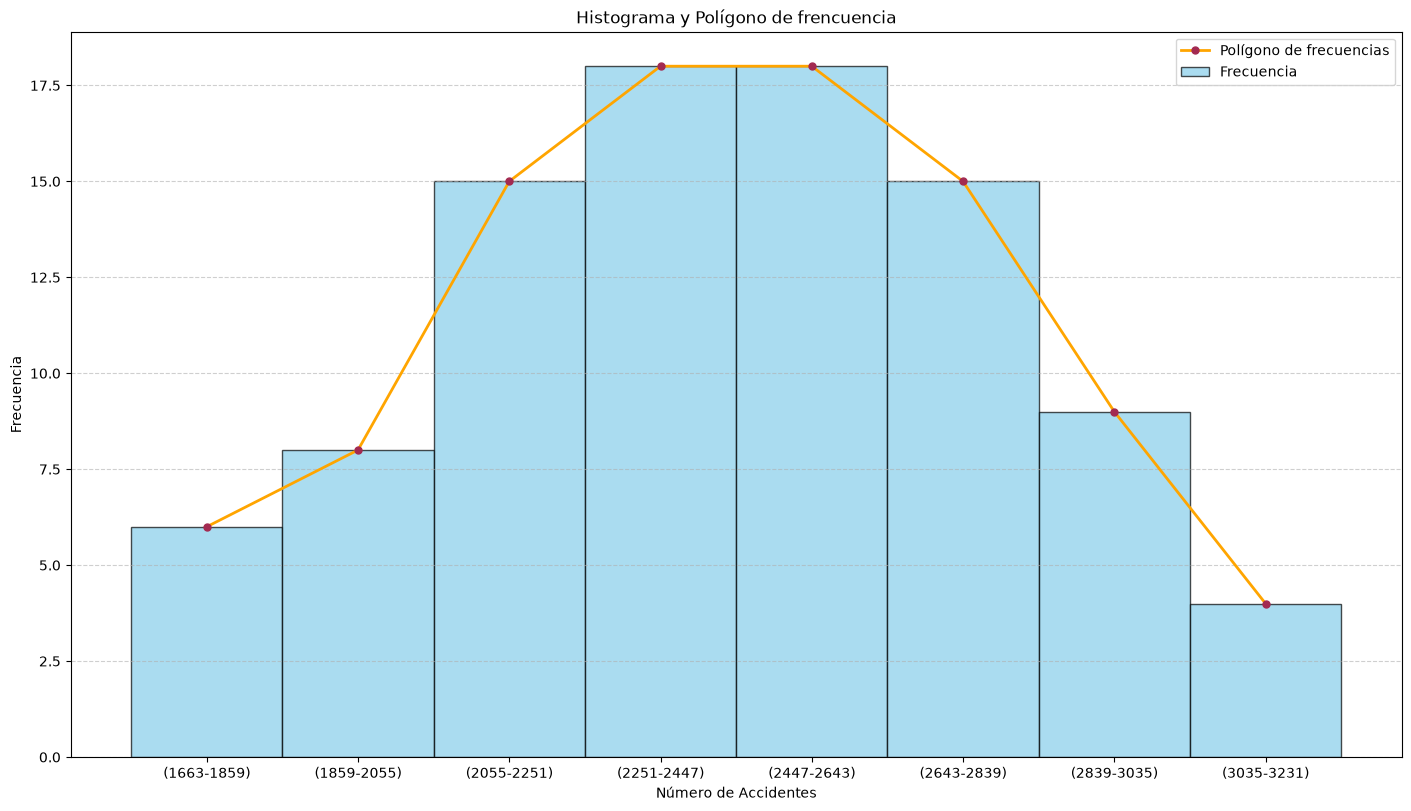

In [69]:
# Histograma y polígono de frecuencia de la variable Accidentes

# Calcular frecuencias e intervalos
frecuencias, intervalos = np.histogram(df["Accidentes"], bins=8)

# Crear un array con los intervalos
bins = []
for index, value in enumerate(intervalos):
    if index <= 7:
        bins.append((int(value), int(intervalos[index+1])))

# Calcular las marcas de clase
Marcas_de_clase = [(a+b)/2 for a, b in bins]

# Cambiar el formato de los intervalos para el eje x
labels = [f"({a}-{b})" for a,b in bins]

# Calcular las anchuras de clase
Anchura = (bins[0][1] - bins[0][0])

plt.figure(figsize=(14,8), constrained_layout=True)
plt.bar(Marcas_de_clase, frecuencias, width=Anchura, align='center', edgecolor='black', color="skyblue",alpha=0.7,label="Frecuencia")
plt.plot(Marcas_de_clase, frecuencias, marker=".", markersize=10, markerfacecolor="#a32a51", markeredgecolor="#a32a51", linestyle="solid",
        linewidth=2, color="orange", label="Polígono de frecuencias")
plt.xticks(Marcas_de_clase, labels)
plt.title("Histograma y Polígono de frencuencia")
plt.xlabel("Número de Accidentes")
plt.ylabel("Frecuencia")



# Cuadrícula y leyenda
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend()
plt.show()


El histograma muestra que la mayoría de los meses presentan entre aproximadamente 2251 y 2643 accidentes, concentración que coincide con el intervalo de mayor frecuencia (18 meses en cada uno de los dos intervalos centrales). La distribución cae de forma bastante simétrica hacia ambos lados de ese centro. Los valores extremos son poco frecuentes: 6 meses registran entre 1663 y 1859 accidentes, y apenas 4 meses superan los 3035. Esto sugiere una distribución simétrica.

In [70]:
# Calcular las medidas de tendencia central de la variable Accidentes

media = df["Accidentes"].mean()
mediana = df["Accidentes"].median()
moda = df["Accidentes"].mode()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana}")
print(f"Moda: ")
for x in moda:
    print(x)

Media: 2440.47
Mediana: 2435.0
Moda: 
1967
2269
2457


La media de 2440.47 y la mediana de 2435.0 son muy cercanas entre sí, lo que confirma la simetría observada en el histograma: no hay indicios de sesgo marcado ni de valores extremos que distorsionen el promedio. Tambien se puede observar que la variable accidentes es multimodal (1967, 2269 y 2457), con cada valor repitiéndose solo 2 veces, esto significa que pierde utilidad como medida de tendencia central, ya que no logra capturar un "valor típico".

In [71]:
# Calcular las medidas de dispersión de la variable Accidentes.

print(f"Rango: {df["Accidentes"].max()-df["Accidentes"].min():.2f}")
print(f"Varianza: {df["Accidentes"].var(ddof=0):.2f}")
print(f"Desviación estándar: {df["Accidentes"].std(ddof=0):.2f}")
cv = (df["Accidentes"].std() / df["Accidentes"].mean()) * 100
print(f"Coeficiente de variación: {cv:.2f}%")

Rango: 1568.00
Varianza: 131625.52
Desviación estándar: 362.80
Coeficiente de variación: 14.95%


La variable Accidentes presenta una desviación estándar de 362.80, lo que indica que los valores mensuales se alejan en promedio ±363 accidentes respecto a la media de 2440.47. El coeficiente de variación (14.95%) confirma que esta dispersión es baja-moderada en términos relativos, sugiriendo que, si bien existen fluctuaciones mes a mes, el comportamiento de la accidentalidad es relativamente estable a lo largo del periodo analizado, sin cambios extremos o erráticos. 

In [72]:
# Coeficiente de Asimetría de Pearson 
asimetria = (3 * (media - mediana)) / df["Accidentes"].std(ddof=0)

print("Coeficiente de Asimetría de Pearson: ", float.__round__(asimetria, 3))

# Curtosis
curt = kurtosis(df["Accidentes"])

print("Curtosis: ", float.__round__(curt, 3))

Coeficiente de Asimetría de Pearson:  0.045
Curtosis:  -0.684


El coeficiente de asimetría de Pearson de 0.045 confirma que la distribución de Accidentes es prácticamente simétrica, sin sesgo relevante hacia ningún lado, resultado consistente con la cercanía observada entre la media y la mediana. Por su parte, la curtosis de -0.684 indica una distribución platicúrtica: más plana que una distribución normal, con los datos repartidos de forma más uniforme a lo largo del rango y sin una concentración marcada alrededor del valor central. En conjunto, estos resultados sugieren que la accidentalidad mensual se comporta de forma bastante estable y predecible, sin sesgos ni comportamientos extremos que distorsionen la distribución.

## Análisis descriptivo de las variables independientes

Además de la variable objetivo (Accidentes), el proyecto considera un conjunto de variables independientes que podrían influir en la frecuencia de accidentes de tránsito en la provincia de Panamá.

En esta sección se presenta un análisis descriptivo de las principales variables cuantitativas utilizadas en el modelo de regresión lineal múltiple: temperatura promedio del mes, acumulación de lluvia diaria, precio de la gasolina de 95 octanos e Índice Mensual de Actividad Económica (IMAE).

Para cada variable se calcularon medidas de dispersión y cuartiles con el objetivo de comprender su comportamiento, evaluar su variabilidad y conocer cómo se distribuyen los datos antes de desarrollar el modelo predictivo.

## Temperatura pormedio del mes
La temperatura promedio mensual es una variable climatica que representa las condiciones ambientales registradasdurante cada mes del periodo analizado. Su estudio permite determinar el grado de variabilidad de la temperatura y posteriormente evaluar si existe alguna relación con la frecuencia de accidentes de tránsito.

In [73]:
print("="*50)
print("TEMPERATURA PROMEDIO")
print("="*50)
temperatura = df["Temperatura Prom. del Mes (°C)"]

print("Rango:", temperatura.max() - temperatura.min())
print("Varianza:", temperatura.var())
print("Desviación estándar:", temperatura.std())

print("\nCuartiles")
print(temperatura.quantile([0.25, 0.50, 0.75]))

TEMPERATURA PROMEDIO
Rango: 3.0500000000000007
Varianza: 0.3979967274427301
Desviación estándar: 0.6308698181421664

Cuartiles
0.25    27.15
0.50    27.50
0.75    27.85
Name: Temperatura Prom. del Mes (°C), dtype: float64


### Interpretación
Los resultados muestran que la temperatura promedio mensual presenta una variabilidad relativamente baja durante el período de estudio. Este comportamiento es consistente con las características climáticas de Panamá, donde las temperaturas suelen mantenerse estables a lo largo del año.

Los cuartiles permiten observar cómo se distribuyen los valores de temperatura dentro del conjunto de datos y sirven como referencia para comparar los distintos períodos analizados. Aunque la temperatura no presenta cambios tan pronunciados como otras variables, se incluye dentro del modelo para evaluar su posible influencia sobre la cantidad de accidentes de tránsito.

## Acumulación de Lluvia Diaria

La acumulación de lluvia diaria representa el nivel de precipitación registrado durante el período analizado. Debido a que las condiciones meteorológicas pueden afectar la visibilidad y el estado de las vías, esta variable constituye uno de los factores de mayor interés dentro del estudio.

In [74]:
print("="*50)
print("ACUMULACIÓN DE LLUVIA")
print("="*50)

print("Rango:", df["Acum. Lluvia Diaria"].max() - df["Acum. Lluvia Diaria"].min())

print("Varianza:", df["Acum. Lluvia Diaria"].var())

print("Desviación estándar:", df["Acum. Lluvia Diaria"].std())

print("\nCuartiles")

print(df["Acum. Lluvia Diaria"].quantile([0.25,0.50,0.75]))

ACUMULACIÓN DE LLUVIA
Rango: 449.0
Varianza: 12986.59883473586
Desviación estándar: 113.95875935940975

Cuartiles
0.25     26.90
0.50    189.65
0.75    247.50
Name: Acum. Lluvia Diaria, dtype: float64


### Interpretación

La acumulación de lluvia presenta una variabilidad mayor que la observada en la temperatura promedio, lo cual refleja las diferencias entre la estación seca y la estación lluviosa en Panamá.

El análisis de los cuartiles permite identificar la distribución de los niveles de precipitación durante el período estudiado. Debido a la influencia que la lluvia puede tener sobre las condiciones de conducción, esta variable resulta especialmente importante para el desarrollo del modelo de regresión lineal múltiple.

## Precio de la Gasolina (95 Octanos)

El precio de la gasolina representa un indicador económico que puede influir indirectamente sobre la movilidad vehicular. Su inclusión dentro del análisis permite evaluar si las variaciones en el costo del combustible presentan alguna relación con la frecuencia de accidentes registrados.

In [75]:
print("="*50)
print("PRECIO GASOLINA")
print("="*50)

print("Rango:", df["Precio Gasolina (95 Octanos)"].max() - df["Precio Gasolina (95 Octanos)"].min())

print("Varianza:", df["Precio Gasolina (95 Octanos)"].var())

print("Desviación estándar:", df["Precio Gasolina (95 Octanos)"].std())

print("\nCuartiles")

print(df["Precio Gasolina (95 Octanos)"].quantile([0.25,0.50,0.75]))

PRECIO GASOLINA
Rango: 0.81
Varianza: 0.02364925198690977
Desviación estándar: 0.1537831329727346

Cuartiles
0.25    0.81
0.50    0.90
0.75    1.04
Name: Precio Gasolina (95 Octanos), dtype: float64


### Interpretación

El precio de la gasolina presenta variaciones moderadas durante el período analizado. Aunque esta variable no describe directamente el comportamiento de los accidentes, puede estar relacionada con la cantidad de desplazamientos realizados por la población y, por consiguiente, con la exposición al riesgo de accidentes.

Su incorporación al modelo permitirá evaluar estadísticamente si existe alguna relación significativa entre ambas variables.

## Índice Mensual de Actividad Económica (IMAE)

El Índice Mensual de Actividad Económica (IMAE) constituye un indicador del comportamiento de la economía nacional. En este proyecto se incorpora como una variable independiente con el propósito de analizar si el nivel de actividad económica puede influir sobre la frecuencia de accidentes de tránsito.

In [76]:
print("="*50)
print("IMAE")
print("="*50)

print("Rango:", df["IMAE"].max() - df["IMAE"].min())

print("Varianza:", df["IMAE"].var())

print("Desviación estándar:", df["IMAE"].std())

print("\nCuartiles")

print(df["IMAE"].quantile([0.25,0.50,0.75]))

IMAE
Rango: 120.04000000000002
Varianza: 1645.0834166432915
Desviación estándar: 40.55962791549365

Cuartiles
0.25    252.14
0.50    271.99
0.75    327.45
Name: IMAE, dtype: float64


### Interpretación

El IMAE presenta variaciones graduales durante el período estudiado, reflejando cambios en la actividad económica del país. La información obtenida mediante las medidas de dispersión y los cuartiles permite comprender el comportamiento de esta variable antes de incorporarla al modelo de regresión.

Su análisis resulta relevante debido a que un incremento en la actividad económica podría asociarse con una mayor movilidad de personas y vehículos, lo que eventualmente podría influir en la cantidad de accidentes registrados.

## Modelo de regresión lineal multiple

<Axes: >

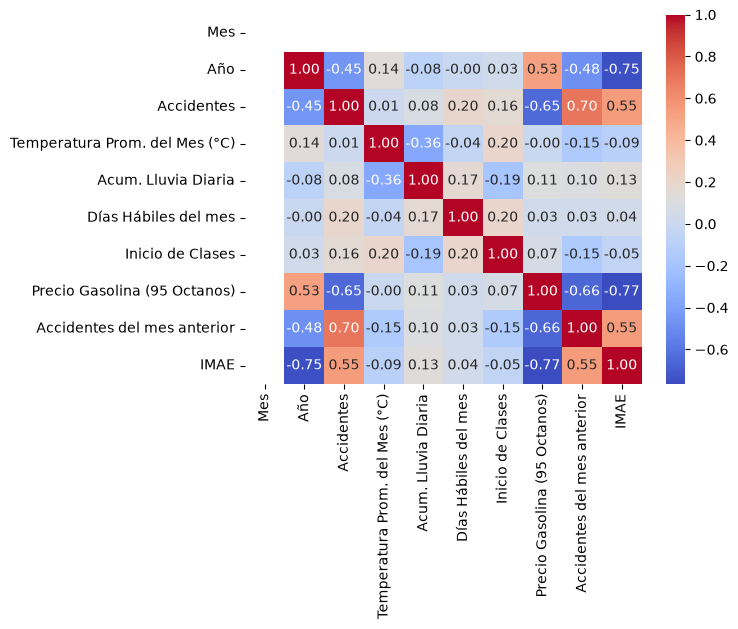

In [79]:
meses = {'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,'Junio':6,
         'Julio':7,'Agosto':8,'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12}

df['Mes'] = df['Mes'].map(meses)

#Generar mapa de calor de correlaciones

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

La accidentalidad se explica principalmente por su propia inercia temporal (Accidentes del mes anterior, r=0.70) y por factores económicos: Precio Gasolina (r=-0.65) e IMAE (r=0.55), mientras que las variables climáticas (Temperatura y Lluvia) no muestran relación relevante con el target.

Un hallazgo adicional relevante es que estas mismas variables económicas están fuertemente correlacionadas entre sí (Precio Gasolina vs. IMAE, r=-0.77; Año vs. IMAE, r=-0.75), lo que sugiere que no aportan información completamente independiente y podrían generar multicolinealidad si se usan juntas en un modelo predictivo.

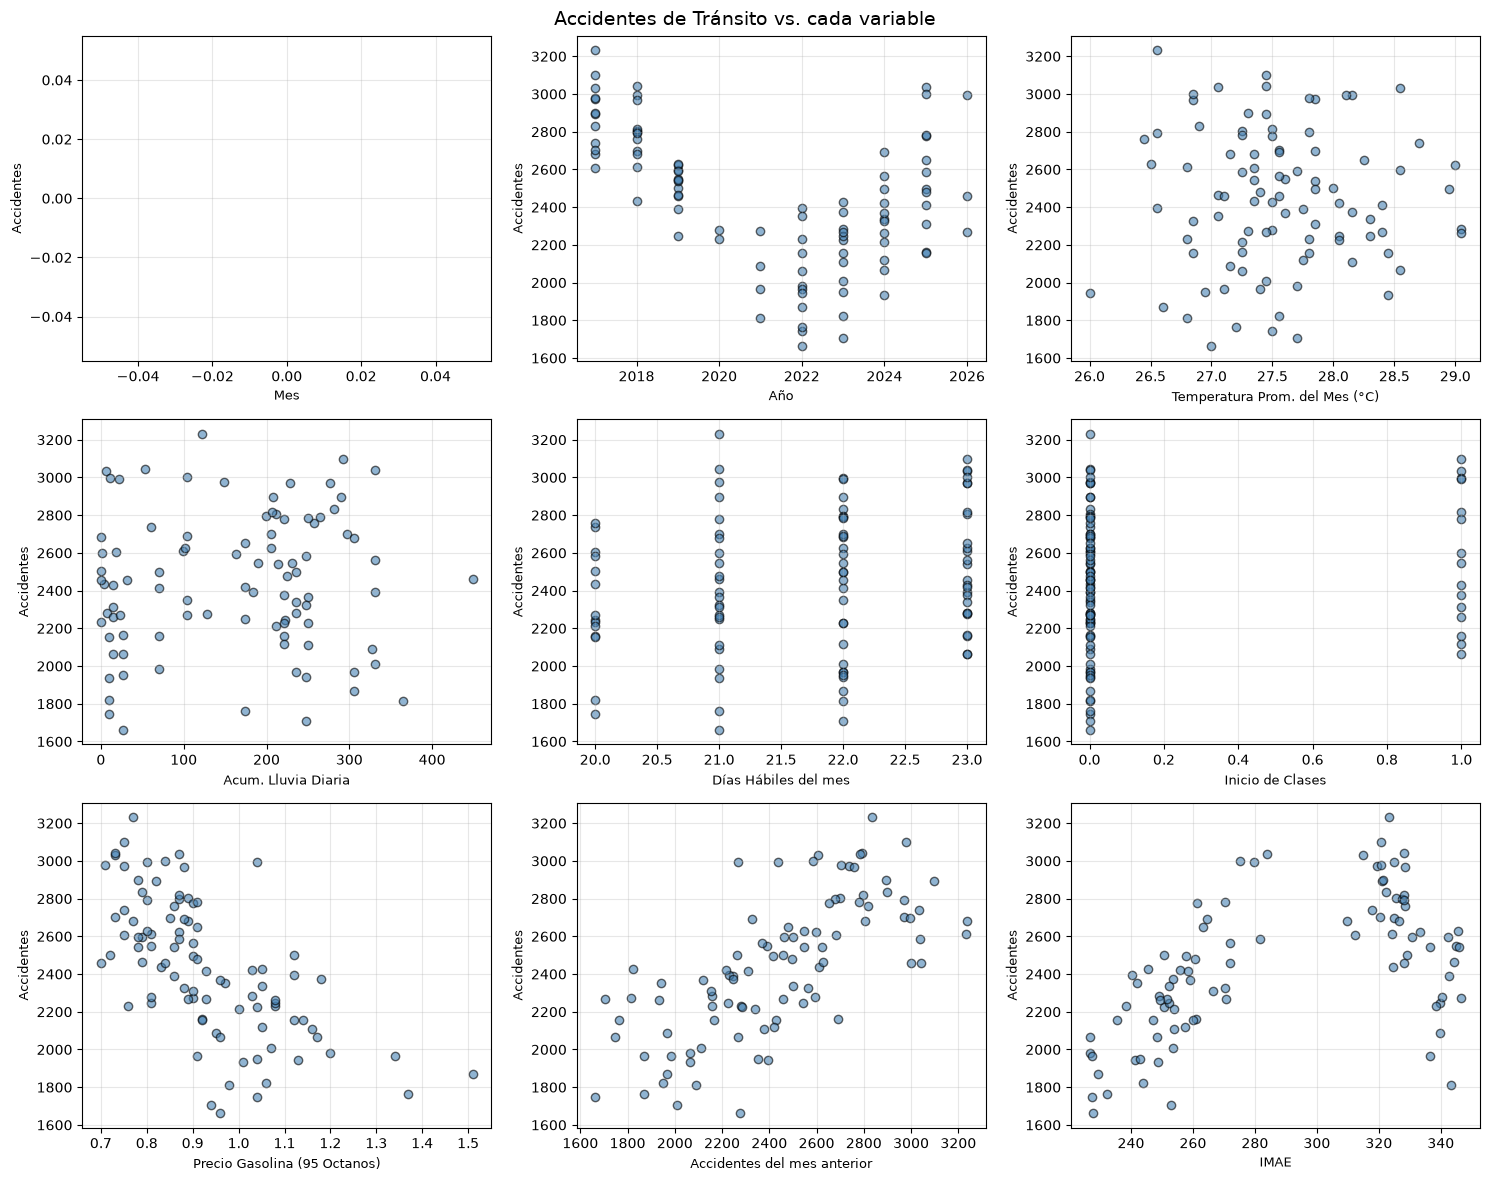

In [80]:
features = ['Mes', 'Año', 'Temperatura Prom. del Mes (°C)', 'Acum. Lluvia Diaria',
            'Días Hábiles del mes', 'Inicio de Clases', 'Precio Gasolina (95 Octanos)',
            'Accidentes del mes anterior', 'IMAE']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['Accidentes'], alpha=0.6, color='steelblue', edgecolor='black')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Accidentes', fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('Accidentes de Tránsito vs. cada variable', fontsize=14)
plt.tight_layout()
plt.show()

Los diagramas de dispersión confirman visualmente los hallazgos de la matriz de correlación: Accidentes del mes anterior, Precio Gasolina e IMAE muestran relaciones claras con la variable objetivo, mientras que Temperatura y Lluvia no presentan ningún patrón.

In [81]:
features = features = ['Accidentes del mes anterior', 'Precio Gasolina (95 Octanos)', 'Año']

X = df[features]
y = df['Accidentes']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.51,-698.23, -3.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Accidentes del mes anterior','Precio Gasolina (95 Octanos)','Año']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9695
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
import numpy as np

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')


print(f"MAE:  {mae:.0f} accidentes")
print(f"RMSE: {rmse:.0f} accidentes")
print(f"R² por fold: {scores}")
print(f"R² promedio (CV): {scores.mean():.3f} ± {scores.std():.3f}")

MAE:  171 accidentes
RMSE: 212 accidentes
R² por fold: [0.62937771 0.52275065 0.36107567 0.36452111 0.52244321]
R² promedio (CV): 0.480 ± 0.103


El modelo de regresión lineal, evaluado mediante validación cruzada (5 folds), explica en promedio un 48% de la variabilidad de Accidentes (R² = 0.480 ± 0.103), con un error absoluto promedio de 171 accidentes y un error cuadrático medio de 212 accidentes. Esto indica un desempeño moderado: el modelo captura una parte importante de la relación entre las variables predictoras y la accidentalidad, pero aún queda una porción considerable de la variabilidad sin explicar, probablemente asociada a factores no incluidos en el modelo o a la naturaleza no completamente lineal de algunas relaciones.